In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, recall_score, \
							precision_score, precision_recall_curve, roc_curve, auc
import scorecardpy as sc
from scorecardpy import woebin, woebin_ply, scorecard
import warnings
import os
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, 
                              roc_auc_score,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_curve)
from sklearn.model_selection import GridSearchCV


In [7]:
absolute_path = os.path.dirname(os.getcwd())
data_path = os.path.join(absolute_path, "data", "kaggle")


## **Data y PreProcesamiento de datos**


### 🛠️ **Especificación de Variables**

| N° | Variable | Descripción | 
| :---: | :--- | :--- | 
| **1** | `age` | edad del solicitante
| **2** | `income` | ingreso mensuals. |
| **3** | `employment_years` | años de empleo | 
| **4** | `credit_history_length` | años de historial crediticio |
| **5** | `num_open_accounts` | número de cuentas abiertas | 
| **6** | `num_credit_inquiries` | número de consultas crediticias recientes | 
| **7** | `loan_amount` | monto solicitado| 
| **8** | `credit_utilization` | proporción de crédito utilizado | 
| **9** | `savings_balance` | balance en cuentas de ahorro|
| **10** | `debt_to_income` | ratio deuda / ingreso | 
| **11** | `savings_to_loan` | ratio ahorro / préstamo |
| **12** | `default` | 1 = incumplimiento | 


In [8]:
df1 = pd.read_csv(os.path.join(data_path, "train.csv"))
df = df1.iloc[:, 1:] #quitamos el customer_id, para fines de modelamiento
df.head()

,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
0,33,2348.508502,11.609655,12.518307,4,2,3128.634506,0.400894,441.505358,1.332179,0.141118,0
1,57,4823.815137,29.366507,29.231106,4,0,17589.950904,0.230374,6564.147572,3.646481,0.373176,0
2,35,2940.413100,20.136902,25.354618,3,2,3988.284147,0.373365,2604.801611,1.356369,0.653113,0
3,29,4381.170349,13.005250,18.376884,4,3,9502.451646,0.280574,2771.703813,2.168930,0.291683,1
4,52,1791.573390,31.344486,30.000000,5,5,5054.886087,0.068373,1894.061920,2.821479,0.374699,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   int64  
 1   income                 5721 non-null   float64
 2   employment_years       5674 non-null   float64
 3   credit_history_length  5716 non-null   float64
 4   num_open_accounts      6000 non-null   int64  
 5   num_credit_inquiries   6000 non-null   int64  
 6   loan_amount            6000 non-null   float64
 7   credit_utilization     5690 non-null   float64
 8   savings_balance        5676 non-null   float64
 9   debt_to_income         6000 non-null   float64
 10  savings_to_loan        6000 non-null   float64
 11  default                6000 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 562.6 KB


Vemos missing values, vamos a analizar esos missing values; veremos un método para tratarlos

In [10]:
df.isnull().sum().to_frame().sort_values(by=0, ascending=False)

,0
employment_years,326
savings_balance,324
credit_utilization,310
credit_history_length,284
income,279
age,0
num_open_accounts,0
num_credit_inquiries,0
loan_amount,0
debt_to_income,0


In [11]:
df.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100

,employment_years,savings_balance,credit_utilization,credit_history_length,income,age,num_open_accounts,num_credit_inquiries,loan_amount,debt_to_income,savings_to_loan,default
0,5.433333,5.4,5.166667,4.733333,4.65,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Cuando tenemos variables que tienen más del 5% de datos perdidos, una decisión equivocada es eliminarlo, dado que, podríamos estar causando pérdida de información; antes de aplicar alguna técnica de tratamiento con los missing values veremos las distribuciones de cada variable.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'employment_years'}>],
       [<Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>,
        <Axes: title={'center': 'num_credit_inquiries'}>],
       [<Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>,
        <Axes: title={'center': 'savings_balance'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

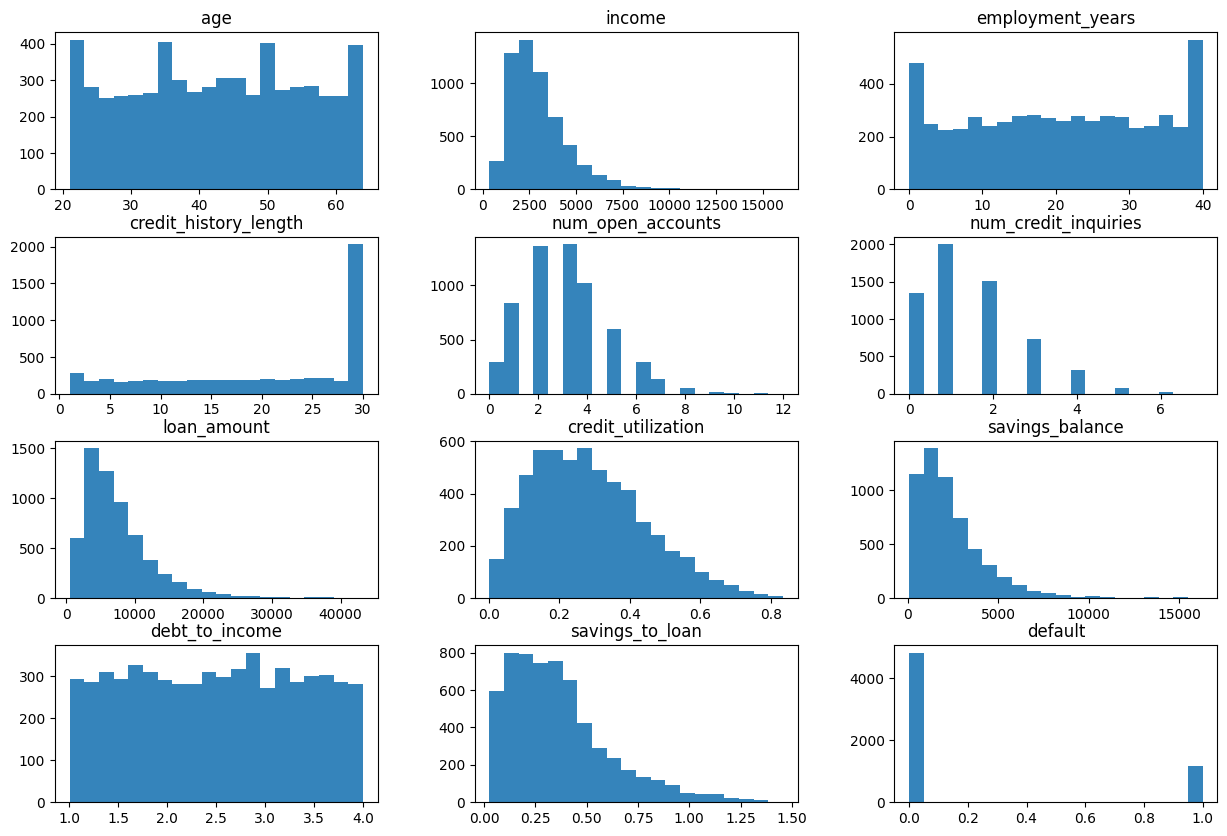

In [12]:
df.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

Veremos que tipo de missing value son las variables que presentan valores nulos: **employment_years, savings_balance, 	credit_utilization, credit_history_length, income**	

<Axes: >

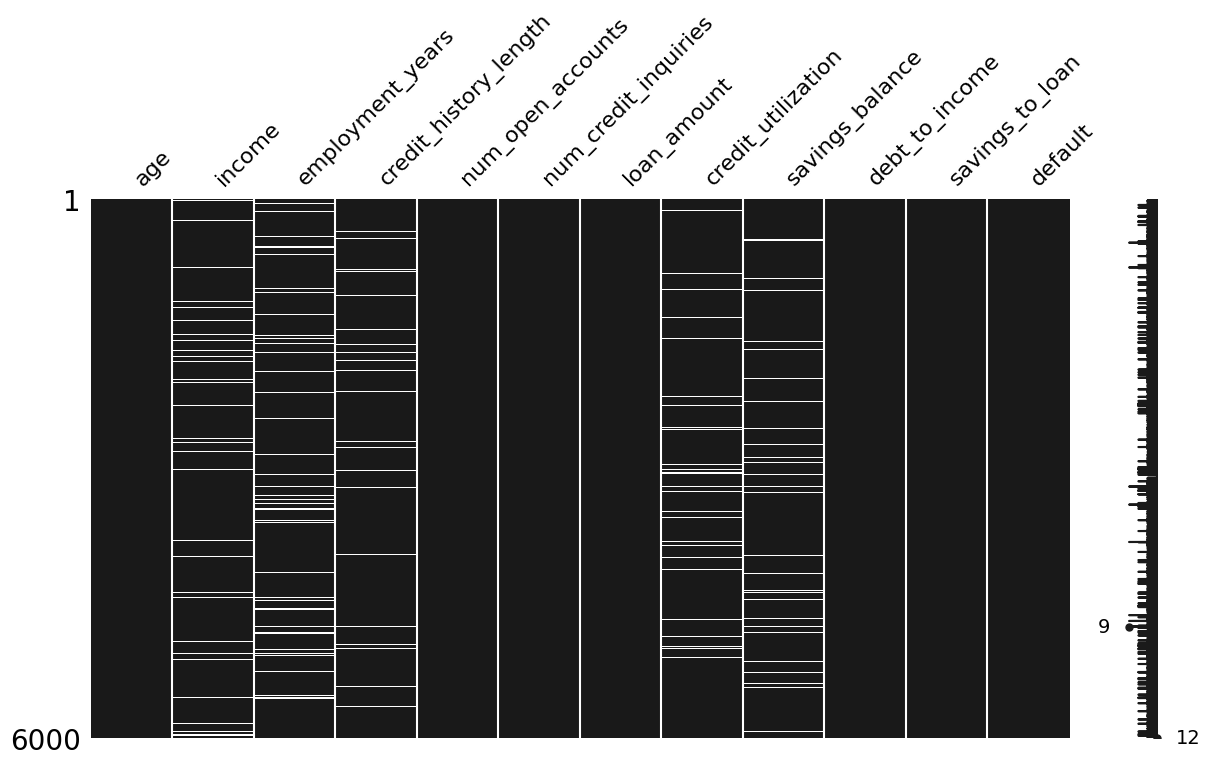

In [13]:
msno.matrix(df, figsize=(14, 7), color=(0.1, 0.1, 0.1))


Parece que se tratase de MAR; por ejemplo en **income** también tiene rayas blancas y parecen coincidir en algunas filas con **employment_years**. Esto sugiere que el nulo en employment_years podría estar relacionado con el nivel de ingreso (por ejemplo: clientes de bajos ingresos con empleo informal: sistema no registra los años). Eso es exactamente MAR.

### Método de imputación de KNN para tratar los missing values

Usaremos la distancia de grower, para realizar las imputaciones; dado que la sospecha es de un MAR, la mediana funciona también; pero primero intentaremos con el método de KNN



In [14]:
# pip install gower
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
import gower

In [15]:
# Creando la función de Knn usando la distancia de Gower para imputar 

def knn_gower_imputer(df, cols_to_impute, k=5):
    """
    Imputa valores nulos usando KNN con distancia de Gower.
    Usa todo el dataframe para calcular similitud entre clientes.
    """
    df_work = df.copy()
    
    for col in cols_to_impute:
        missing_idx = df_work[df_work[col].isnull()].index
        present_idx = df_work[df_work[col].notna()].index
        
        if len(missing_idx) == 0:
            print(f"  {col}: sin nulos, se omite.")
            continue
        
        print(f"  Imputando '{col}' → {len(missing_idx)} nulos...")
        
        # Usa todo el df excepto la columna objetivo para calcular distancias
        features = df_work.drop(columns=[col])
        
        dist = gower.gower_matrix(
            features.loc[missing_idx],
            features.loc[present_idx]
        )
        
        for i, idx in enumerate(missing_idx):
            k_neighbors = present_idx[np.argsort(dist[i])[:k]]
            df_work.loc[idx, col] = df_work.loc[k_neighbors, col].median()
        
        print(f"  ✓ '{col}' imputado.")
    
    return df_work



In [16]:
cols_nulas = ['income', 'employment_years', 'savings_balance',
              'credit_utilization', 'credit_history_length']
df_imputed = knn_gower_imputer(df, cols_nulas, k=5)

  Imputando 'income' → 279 nulos...
  ✓ 'income' imputado.
  Imputando 'employment_years' → 326 nulos...
  ✓ 'employment_years' imputado.
  Imputando 'savings_balance' → 324 nulos...
  ✓ 'savings_balance' imputado.
  Imputando 'credit_utilization' → 310 nulos...
  ✓ 'credit_utilization' imputado.
  Imputando 'credit_history_length' → 284 nulos...
  ✓ 'credit_history_length' imputado.


In [17]:
df_imputed.isnull().sum()

age                      0
income                   0
employment_years         0
credit_history_length    0
num_open_accounts        0
num_credit_inquiries     0
loan_amount              0
credit_utilization       0
savings_balance          0
debt_to_income           0
savings_to_loan          0
default                  0
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'employment_years'}>],
       [<Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>,
        <Axes: title={'center': 'num_credit_inquiries'}>],
       [<Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>,
        <Axes: title={'center': 'savings_balance'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

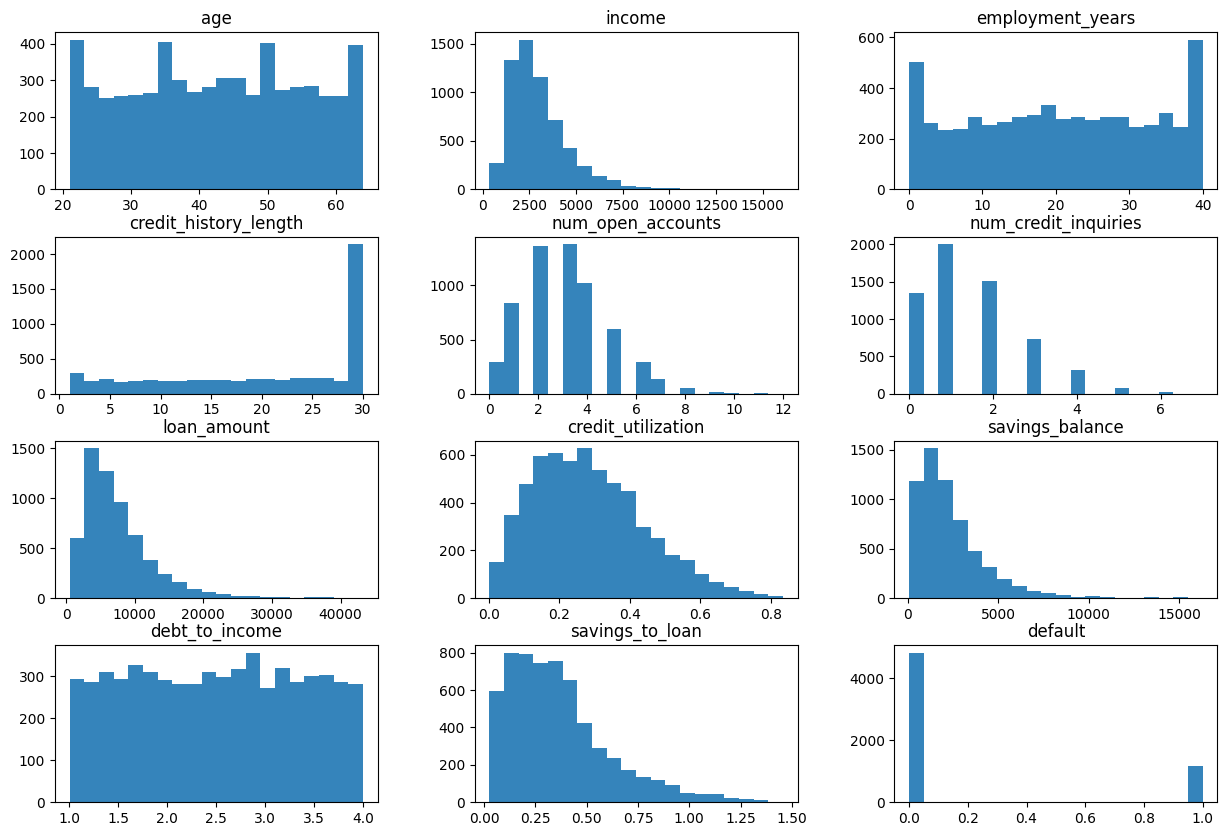

In [18]:
# Distribución de los datos imputados 

df_imputed.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'employment_years'}>],
       [<Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>,
        <Axes: title={'center': 'num_credit_inquiries'}>],
       [<Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>,
        <Axes: title={'center': 'savings_balance'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

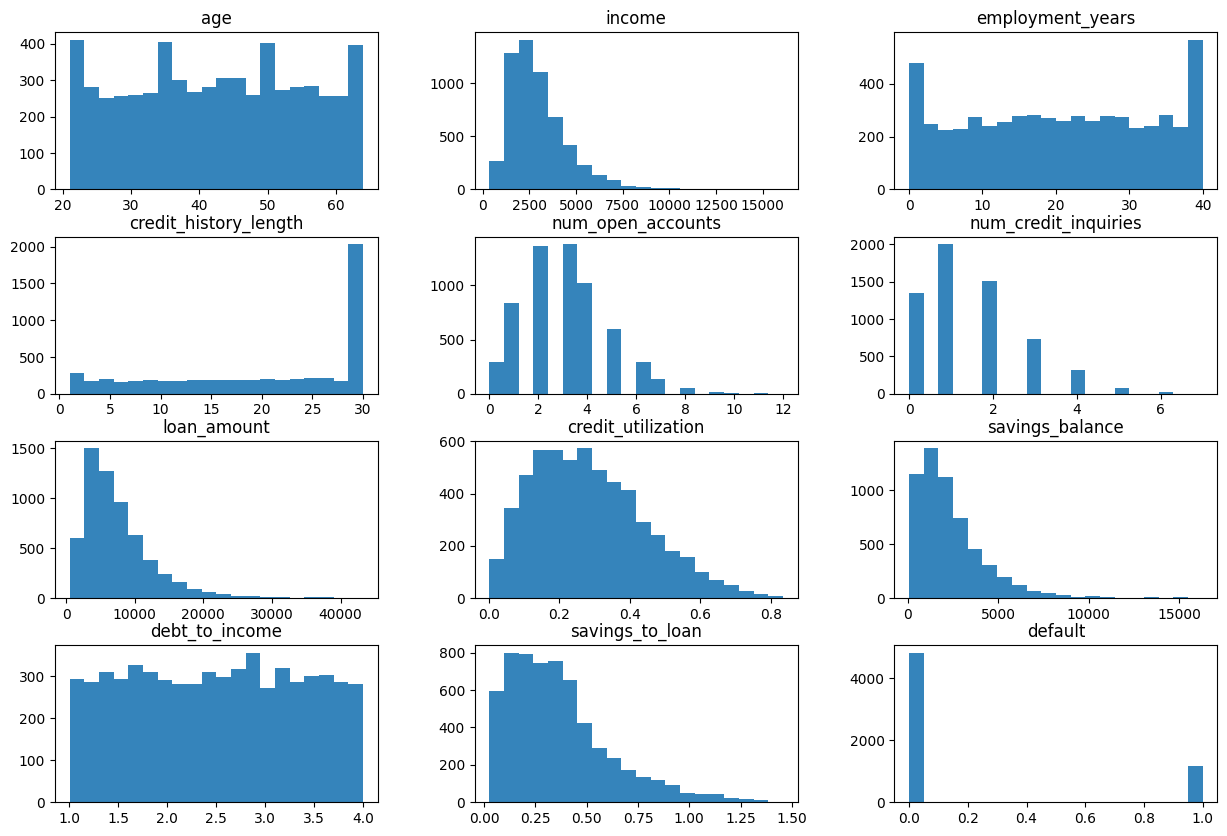

In [19]:
# Distribución de los datos con missing values

df.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

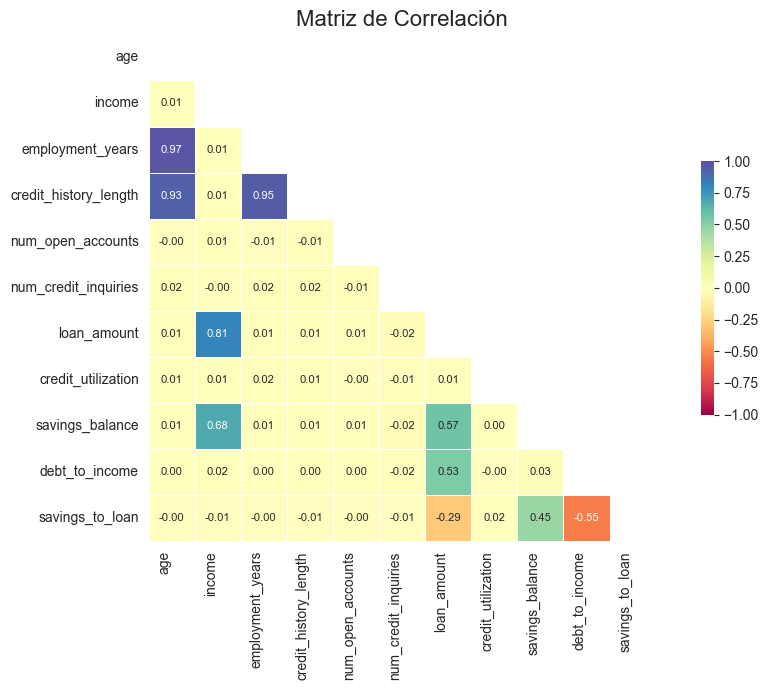

In [20]:
# Variables numéricas (excluye ID y target)
v_num = [c for c in df_imputed.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

corr = df_imputed[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.set_style("white")

sns.heatmap(corr, mask=mask, cmap="Spectral",
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
# Dado que observamos una alta correlación entre mis variables, lo mejor sería desechar las redundantes para evitar problemas de multicolinealidad 
cols_drop = ['age', 'employment_years']
df_clean = df_imputed.drop(columns=cols_drop)
df_clean.columns
# mantenemos credit_history_length, por ser una variable importante en credit scoring

Index(['income', 'credit_history_length', 'num_open_accounts',
       'num_credit_inquiries', 'loan_amount', 'credit_utilization',
       'savings_balance', 'debt_to_income', 'savings_to_loan', 'default'],
      dtype='object')

### OUTLIERS

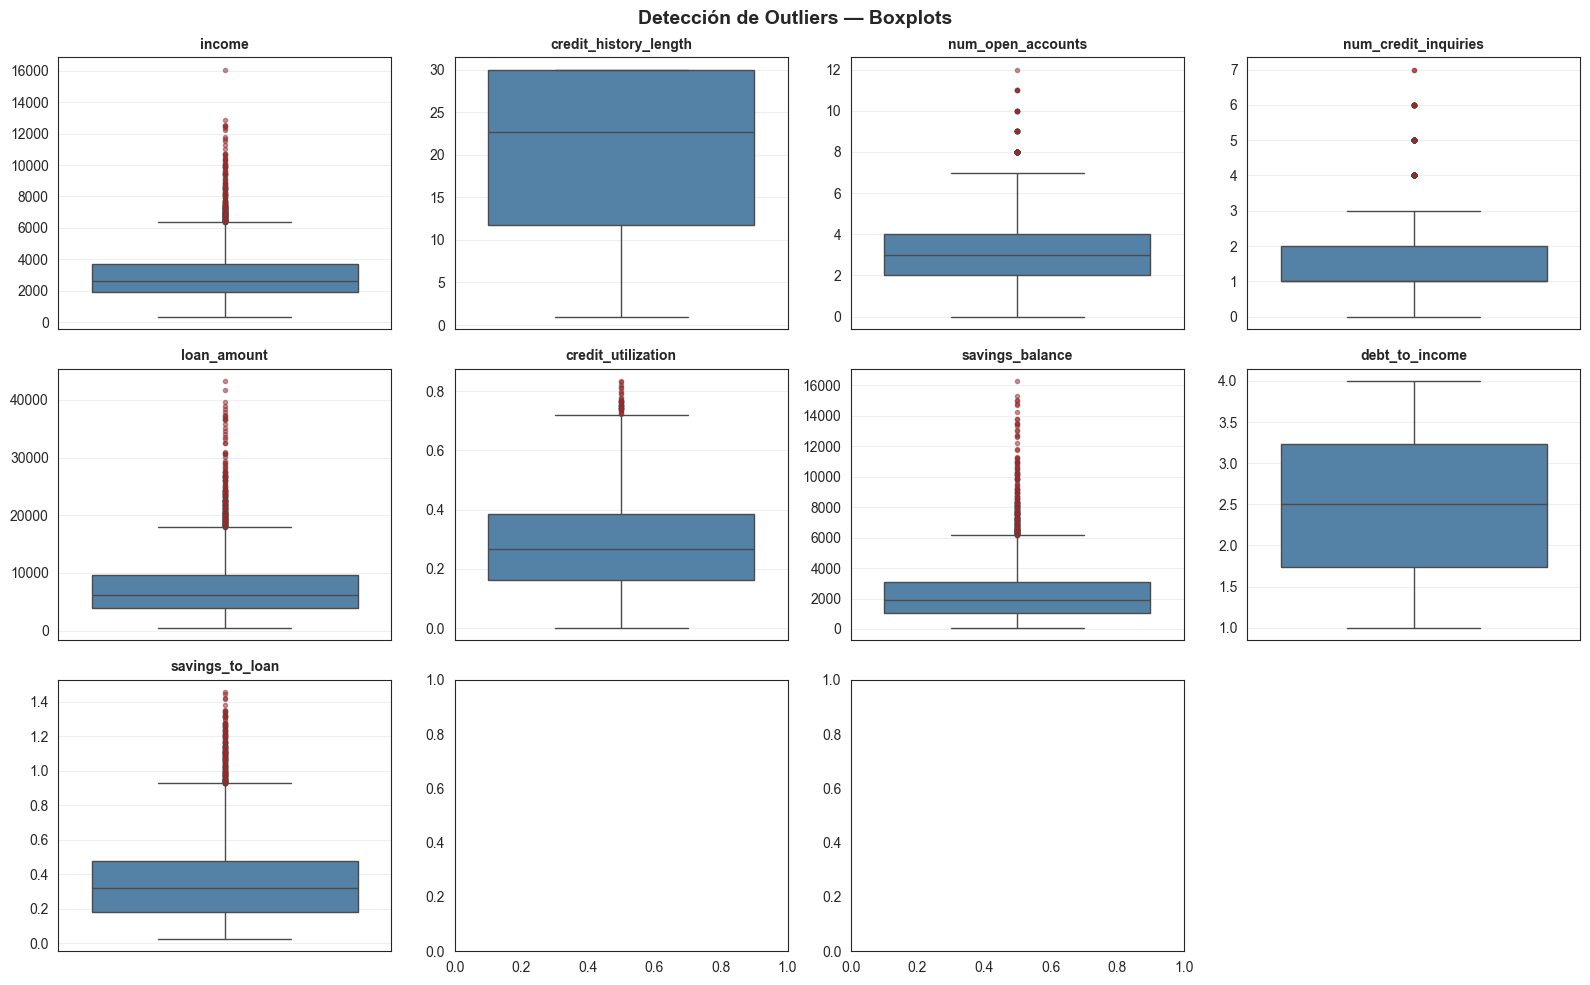

In [22]:
v_num = [c for c in df_clean.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

sns.set_style("white")


for i, col in enumerate(v_num):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='steelblue',
                flierprops=dict(marker='o', markerfacecolor='red', 
                                markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', alpha=0.3)

# Ocultar subplot sobrante (3x4=12 celdas, solo 11 variables)
axes[-1].set_visible(False)

plt.suptitle("Detección de Outliers — Boxplots", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Observamos que hay variables con muchos outliers, por lo tanto debemos tratarla con cuidado, y no evitar crear nuevos patrones

Para tratar ello, vamos a usar el método capping; que es muy usado usando los cuantiles cómo aproximación ante ese outlier y lo reemplaza

In [ ]:
def imputate_outlier(df, col, method="capping"):
    """     
    methods:
        "mean"    → reemplaza outliers con la media
        "median"  → reemplaza outliers con la mediana
        "mode"    → reemplaza outliers con la moda
        "capping" → percentil 5 (inferior) y percentil 95 (superior)
    """
    serie = df[col].copy()
    
    # Detectar outliers por IQR
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    
    mask_out = (serie < lower_iqr) | (serie > upper_iqr)
    
    if method == "capping":
        cap_low  = serie.quantile(0.05)
        cap_high = serie.quantile(0.95)
        serie = serie.clip(lower=cap_low, upper=cap_high)
    
    elif method == "mean":
        fill = serie[~mask_out].mean()
        serie[mask_out] = fill
    
    elif method == "median":
        fill = serie[~mask_out].median()
        serie[mask_out] = fill
    
    elif method == "mode":
        fill = serie[~mask_out].mode()[0]
        serie[mask_out] = fill
    
    return serie


In [26]:
# Lista de variables con outliers detectados
vars_con_outliers = [
    "income", 
    "loan_amount", 
    "savings_balance", 
    "num_open_accounts", 
    "num_credit_inquiries", 
    "savings_to_loan",
    "credit_utilization"
]

# Aplicar capping a todas de una sola vez
df_clean1 = df_clean.copy()

for col in vars_con_outliers:
    df_clean1[col] = imputate_outlier(df_clean1, col, method="capping")

print("Antes:", df_clean[vars_con_outliers].describe().loc[["min","max"]])
print("Después:", df_clean1[vars_con_outliers].describe().loc[["min","max"]])


Antes:            income   loan_amount  savings_balance  num_open_accounts  \
min    350.225728    510.906132        82.006815                0.0   
max  16080.076782  43273.949743     16288.071259               12.0   

     num_credit_inquiries  savings_to_loan  credit_utilization  
min                   0.0         0.025786            0.001339  
max                   7.0         1.456240            0.834712  
Después:           income   loan_amount  savings_balance  num_open_accounts  \
min  1164.320656   2107.956540       397.473967                1.0   
max  5976.460548  17122.323276      5907.698585                6.0   

     num_credit_inquiries  savings_to_loan  credit_utilization  
min                   0.0         0.069300            0.065544  
max                   4.0         0.871958            0.574580  


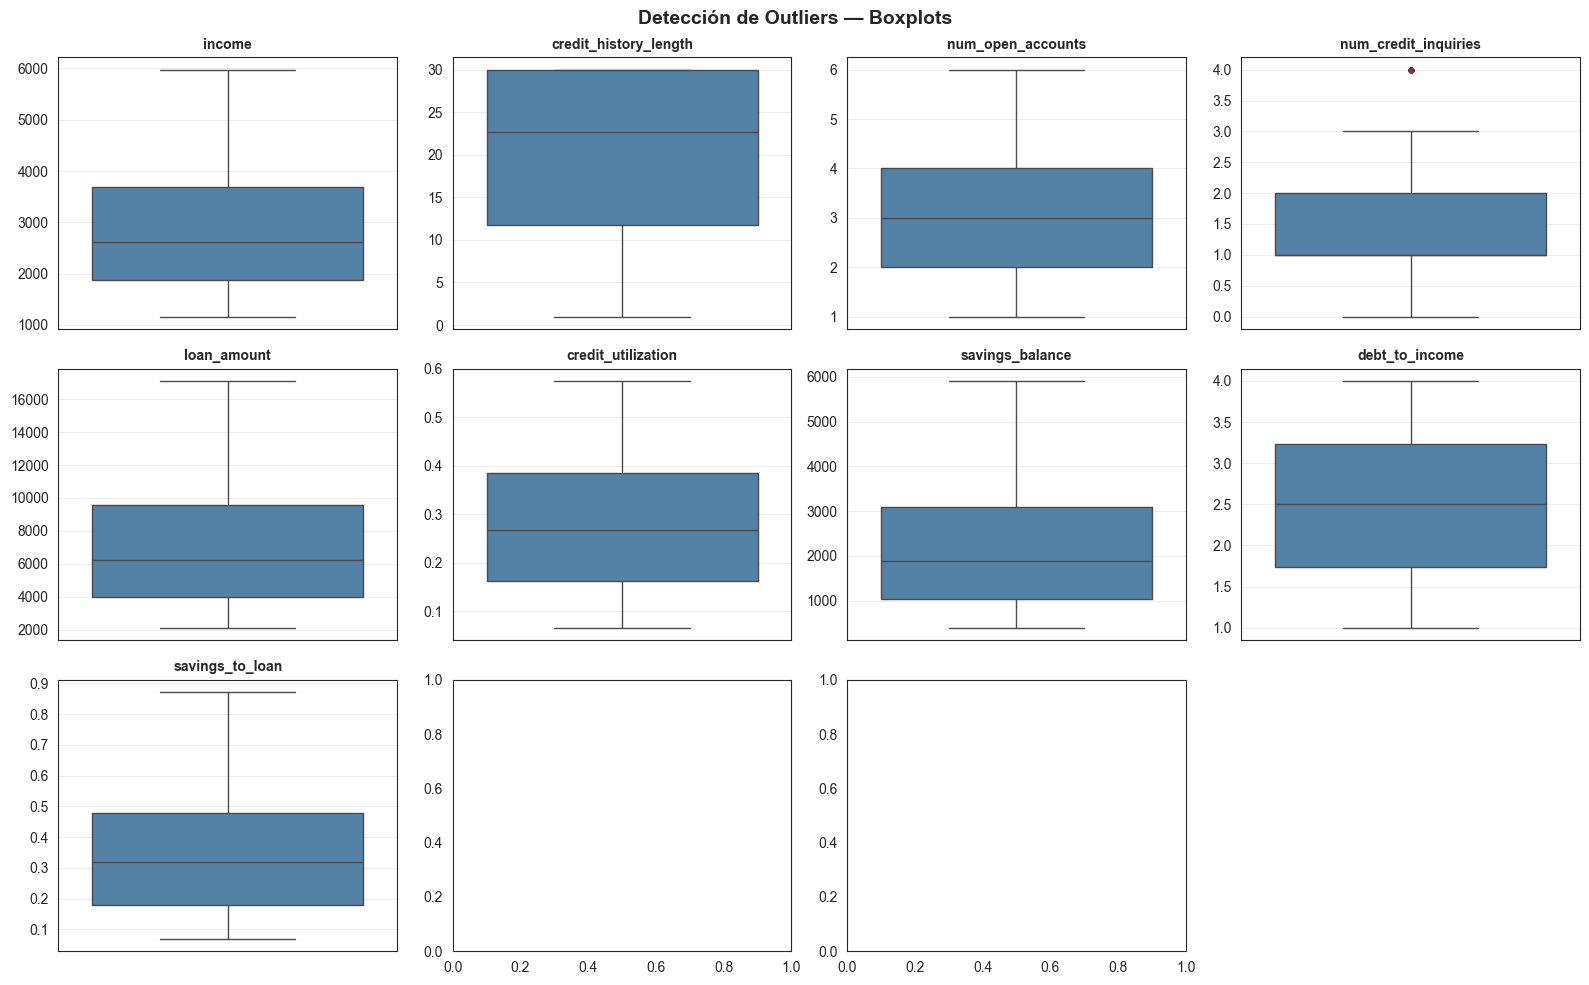

In [27]:
v_num = [c for c in df_clean1.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

sns.set_style("white")


for i, col in enumerate(v_num):
    sns.boxplot(y=df_clean1[col], ax=axes[i], color='steelblue',
                flierprops=dict(marker='o', markerfacecolor='red', 
                                markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', alpha=0.3)

# Ocultar subplot sobrante (3x4=12 celdas, solo 11 variables)
axes[-1].set_visible(False)

plt.suptitle("Detección de Outliers — Boxplots", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'employment_years'}>],
       [<Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>,
        <Axes: title={'center': 'num_credit_inquiries'}>],
       [<Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>,
        <Axes: title={'center': 'savings_balance'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

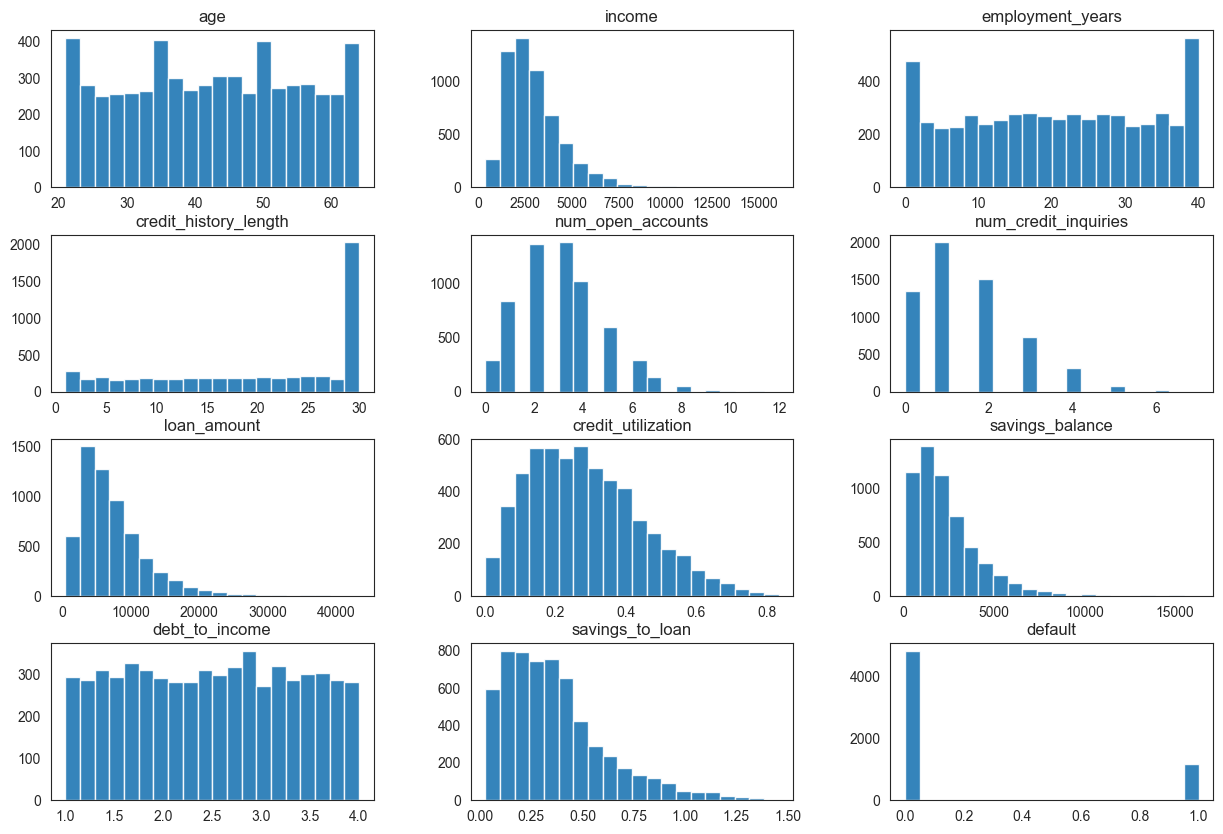

In [29]:
# Comparamos las distribuciones con la data original

# Distribución de la data cruda

df.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

array([[<Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>],
       [<Axes: title={'center': 'num_credit_inquiries'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>],
       [<Axes: title={'center': 'savings_balance'}>,
        <Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>],
       [<Axes: title={'center': 'default'}>, <Axes: >, <Axes: >]],
      dtype=object)

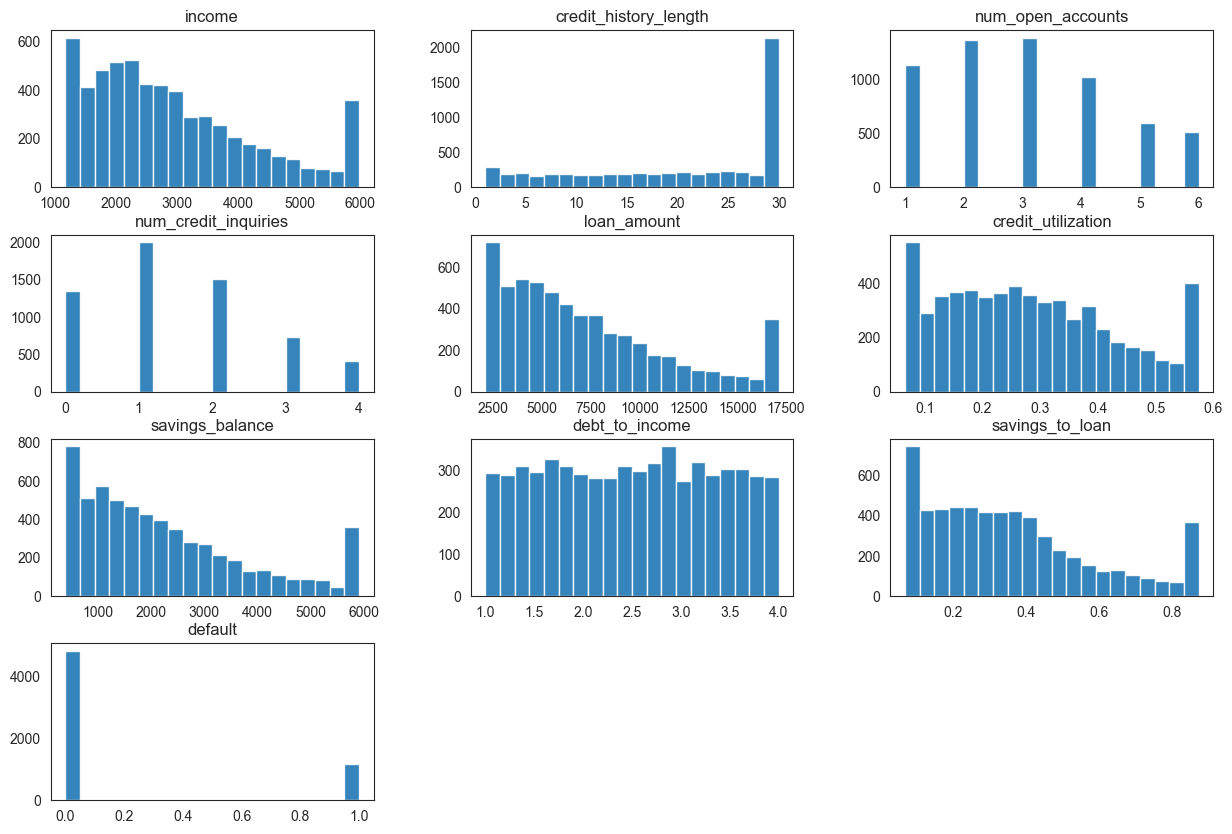

In [31]:
# Distribución de la data limpia tratando los outliers y missing values

df_clean1.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

## **WOE**

WOE mide la evidencia relativa de ser Good vs Bad en un segmento. Es decir, el WOE mide qué tan diferente es la proporción de buenos y malos en cada categoría de una variable.

- WOE > 0: esa categoría tiene más buenos que el promedio → menor riesgo.
- WOE < 0: esa categoría tiene más malos que el promedio → mayor riesgo.
- |WOE| grande → fuerte separación.

Es una forma de transformar categorías en números que un modelo puede entender, manteniendo la lógica.

In [36]:
bins = sc.woebin(df_clean1, y="default")
bins

[INFO] creating woe binning ...


C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C

{'credit_utilization':              variable                                       bin  count  \
 0  credit_utilization                [-inf,0.11999999999999997)    899   
 1  credit_utilization  [0.11999999999999997,0.3099999999999999)   2686   
 2  credit_utilization  [0.3099999999999999,0.48999999999999977)   1746   
 3  credit_utilization                 [0.48999999999999977,inf)    669   
 
    count_distr  good  bad   badprob       woe    bin_iv  total_iv  \
 0     0.149833   777  122  0.135706 -0.438877  0.025107  0.099231   
 1     0.447667  2241  445  0.165674 -0.204061  0.017495  0.099231   
 2     0.291000  1338  408  0.233677  0.224879  0.015725  0.099231   
 3     0.111500   469  200  0.298954  0.560257  0.040905  0.099231   
 
                 breaks  is_special_values  
 0  0.11999999999999997              False  
 1   0.3099999999999999              False  
 2  0.48999999999999977              False  
 3                  inf              False  ,
 'num_open_accounts':  

In [ ]:
# Interpretación de credit_utilization
# Los WOE van de -0.43 a +0.56 — eso significa que a mayor utilización de crédito, mayor probabilidad de default:
# ​

# text
# [-inf, 0.12)  → WOE = -0.44  ← mayor riesgo
# [0.12, 0.30)  → WOE = -0.20  ← riesgo medio
# [0.30, 0.49)  → WOE = +0.22  ← menor medio
# [0.49, inf)   → WOE = +0.56  ← menor riesgo 

C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\woebin.py:1304: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bins = bins.groupby('variable', group_keys=False).apply(gb_distr)


{'credit_history_length': <Figure size 640x480 with 2 Axes>}

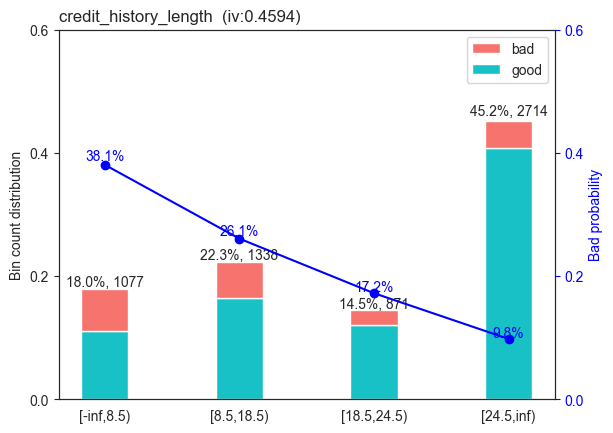

In [38]:
sc.woebin_plot(bins['credit_history_length'])

A mayor historial crediticio, menor probabilidad de default. La línea azul cae de 38.1% a 0.8% de forma consistente y monótona eso es un buen indicativo, aparte el VI es de 0.4 es una variable que discrimina bien. 

In [40]:
# VI
iv_table = sc.iv(df_clean1, y="default")
print(iv_table.sort_values("info_value", ascending=False))


C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after gro

                variable  info_value
2  credit_history_length    0.597915
3        savings_to_loan    0.211999
4        savings_balance    0.169852
8                 income    0.161783
0     credit_utilization    0.136074
5            loan_amount    0.119266
6   num_credit_inquiries    0.036389
1      num_open_accounts    0.017755
7         debt_to_income    0.006993


C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scorecardpy\info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \


In [113]:
good_vars = iv_table.loc[iv_table['info_value'] > 0.0356, 'variable'].tolist()
print(good_vars)

['credit_history_length', 'savings_to_loan', 'savings_balance', 'income', 'credit_utilization', 'loan_amount', 'num_credit_inquiries']


In [114]:
train_sel = df_clean1[good_vars + ['default']]
train_woe = sc.woebin_ply(train_sel, bins)


[INFO] converting into woe values ...


In [115]:
train_woe.head()

,default,credit_utilization_woe,credit_history_length_woe,savings_to_loan_woe,savings_balance_woe,loan_amount_woe,num_credit_inquiries_woe,income_woe
0,0,0.224879,0.370920,0.492521,0.600296,-0.212561,0.089530,0.118044
1,0,-0.204061,-0.806988,0.174051,-1.105751,-0.094001,-0.342350,-0.320392
2,0,0.224879,-0.806988,-0.768965,-0.331589,-0.212561,0.089530,-0.320392
3,1,-0.204061,0.370920,0.174051,-0.331589,0.150007,0.229306,-0.320392
4,0,-0.438877,-0.806988,0.174051,0.038058,0.150007,0.229306,0.401385


## **Modelamiento**

In [116]:
X_train_woe = train_woe.drop(columns=['default'])
y_train_woe = train_woe['default']

In [117]:
# Balanceo en el train 

print("Distribución ANTES del SMOTE:")
print(y_train_woe.value_counts())

smote = SMOTE(k_neighbors=5, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_woe, y_train_woe)

print("\nDistribución DESPUÉS del SMOTE:")
print(y_train_bal.value_counts())

Distribución ANTES del SMOTE:
default
0    4825
1    1175
Name: count, dtype: int64

Distribución DESPUÉS del SMOTE:
default
0    4825
1    4825
Name: count, dtype: int64


In [118]:
# Validación cruzada 

params = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']   # soporta l1 y l2
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid = params,
    cv         = 5,            
    scoring    = 'roc_auc',    
    n_jobs     = -1,           
    verbose    = 1
)

grid.fit(X_train_bal, y_train_bal)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Alberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [125]:
print("Mejores parámetros:", grid.best_params_)
print(f"Mejor AUC (CV):    {grid.best_score_:.4f}")

Mejores parámetros: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor AUC (CV):    0.7918


In [126]:
# escogemos el mejor modelo
best_model = grid.best_estimator_

In [127]:
y_pred_train      = best_model.predict(X_train_bal)
y_pred_prob_train = best_model.predict_proba(X_train_bal)[:, 1]

In [128]:
print("=== TRAIN ===")
print(classification_report(y_train_bal, y_pred_train))

=== TRAIN ===
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      4825
           1       0.71      0.73      0.72      4825

    accuracy                           0.72      9650
   macro avg       0.72      0.72      0.72      9650
weighted avg       0.72      0.72      0.72      9650



AUC-ROC Train: 0.7924


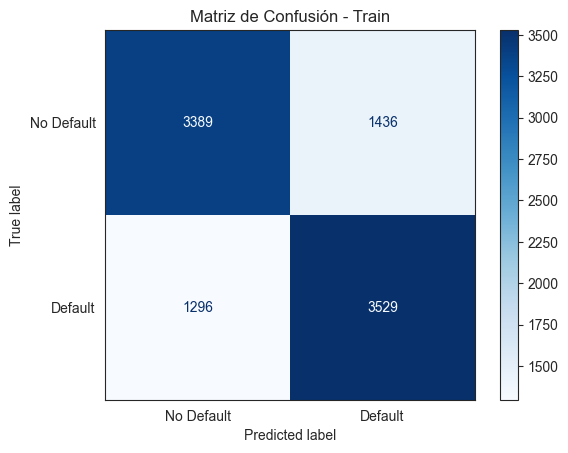

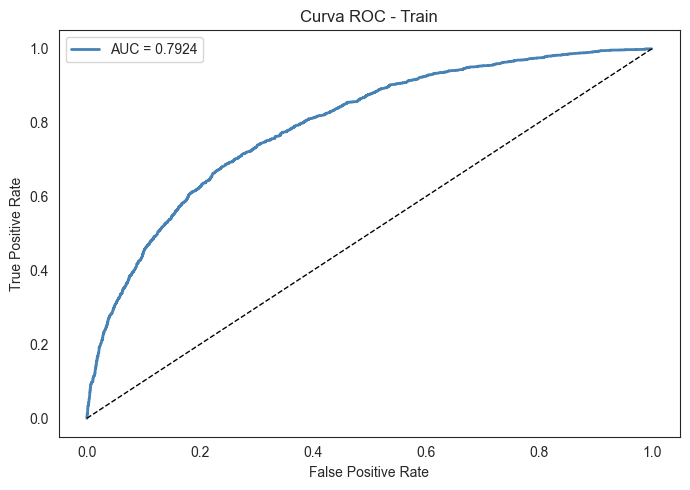

In [129]:
auc = roc_auc_score(y_train_bal, y_pred_prob_train)
print(f"AUC-ROC Train: {float(auc):.4f}")

# Matriz de confusión
cm_train = confusion_matrix(y_train_bal, y_pred_train)
ConfusionMatrixDisplay(cm_train, display_labels=["No Default","Default"]).plot(cmap="Blues")
plt.title("Matriz de Confusión - Train")
plt.show()

fpr, tpr, _ = roc_curve(y_train_bal, y_pred_prob_train)

# Curva ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {float(auc):.4f}", color="steelblue", lw=2)
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Train")
plt.legend()
plt.tight_layout()
plt.show()

## **TEST**

In [74]:
test = pd.read_csv(os.path.join(data_path, "test.csv"))
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            2000 non-null   int64  
 1   age                    2000 non-null   int64  
 2   income                 1895 non-null   float64
 3   employment_years       1910 non-null   float64
 4   credit_history_length  1895 non-null   float64
 5   num_open_accounts      2000 non-null   int64  
 6   num_credit_inquiries   2000 non-null   int64  
 7   loan_amount            2000 non-null   float64
 8   credit_utilization     1908 non-null   float64
 9   savings_balance        1889 non-null   float64
 10  debt_to_income         2000 non-null   float64
 11  savings_to_loan        2000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 187.6 KB


In [ ]:
# Tratamiento de los NAS
cols_nulas = ['income', 'employment_years', 'savings_balance',
              'credit_utilization', 'credit_history_length']
test_imputed = knn_gower_imputer(test, cols_nulas, k=5)

  Imputando 'income' → 105 nulos...
  ✓ 'income' imputado.
  Imputando 'employment_years' → 90 nulos...
  ✓ 'employment_years' imputado.
  Imputando 'savings_balance' → 111 nulos...
  ✓ 'savings_balance' imputado.
  Imputando 'credit_utilization' → 92 nulos...
  ✓ 'credit_utilization' imputado.
  Imputando 'credit_history_length' → 105 nulos...
  ✓ 'credit_history_length' imputado.


In [ ]:
# Eliminamos las altas correlaciones
cols_drop = ['age', 'employment_years']
test_clean = test_imputed.drop(columns=cols_drop)

In [ ]:
# Tratamiento de outliers

vars_con_outliers = [
    "income", 
    "loan_amount", 
    "savings_balance", 
    "num_open_accounts", 
    "num_credit_inquiries", 
    "savings_to_loan",
    "credit_utilization"
]

# Aplicar capping a todas de una sola vez
test_clean1 = test_clean.copy()

for col in vars_con_outliers:
    test_clean1[col] = imputate_outlier(test_clean1, col, method="capping")

print("Antes:", test_clean[vars_con_outliers].describe().loc[["min","max"]])
print("Después:", test_clean1[vars_con_outliers].describe().loc[["min","max"]])


Antes:            income   loan_amount  savings_balance  num_open_accounts  \
min    416.216111    709.347302       106.110339                0.0   
max  15731.360642  52259.452298     21665.218339               10.0   

     num_credit_inquiries  savings_to_loan  credit_utilization  
min                   0.0         0.026379            0.006898  
max                   7.0         1.434538            0.824000  
Después:           income   loan_amount  savings_balance  num_open_accounts  \
min  1195.197217   2128.120002       388.619122                1.0   
max  5970.671912  16718.197317      5874.583794                6.0   

     num_credit_inquiries  savings_to_loan  credit_utilization  
min                   0.0         0.069185            0.061802  
max                   4.0         0.906664            0.578726  


In [130]:


test_woe = sc.woebin_ply(test_clean1, bins)    # mismos bins del train 
X_test = test_woe[[col + "_woe" for col in good_vars]]

print("Test listo:", X_test.shape)
print(X_test.head())

[INFO] converting into woe values ...
Test listo: (2000, 7)
   credit_history_length_woe  savings_to_loan_woe  savings_balance_woe  \
0                   0.370920            -0.768965            -0.331589   
1                  -0.806988             0.174051            -0.331589   
2                   0.370920             0.492521             0.600296   
3                  -0.157461            -0.768965            -0.331589   
4                   0.370920             0.492521            -0.331589   

   income_woe  credit_utilization_woe  loan_amount_woe  \
0   -0.320392               -0.204061         0.150007   
1   -0.320392               -0.204061         0.150007   
2    0.401385                0.560257        -0.450833   
3   -0.320392               -0.204061         0.150007   
4   -0.320392               -0.204061        -0.094001   

   num_credit_inquiries_woe  
0                 -0.342350  
1                  0.089530  
2                 -0.003360  
3                  0.22930

In [131]:
X_test.head()

,credit_history_length_woe,savings_to_loan_woe,savings_balance_woe,income_woe,credit_utilization_woe,loan_amount_woe,num_credit_inquiries_woe
0,0.370920,-0.768965,-0.331589,-0.320392,-0.204061,0.150007,-0.342350
1,-0.806988,0.174051,-0.331589,-0.320392,-0.204061,0.150007,0.089530
2,0.370920,0.492521,0.600296,0.401385,0.560257,-0.450833,-0.003360
3,-0.157461,-0.768965,-0.331589,-0.320392,-0.204061,0.150007,0.229306
4,0.370920,0.492521,-0.331589,-0.320392,-0.204061,-0.094001,0.089530


In [132]:
# Reordenar X_test con el mismo orden del train 
X_test = X_test[X_train_bal.columns.tolist()]
y_prob_test = best_model.predict_proba(X_test)[:, 1]

In [133]:
submission = pd.DataFrame({
    "customer_id": test["customer_id"],   # del CSV original
    "default_probability":     y_prob_test
})

print(submission.head(10))

   customer_id  default_probability
0            2             0.196102
1            3             0.250968
2            4             0.854987
3            5             0.229509
4            9             0.601497
5           10             0.625254
6           16             0.764033
7           34             0.471939
8           36             0.391615
9           38             0.357420


In [134]:
len(submission)

2000

In [135]:
# GUARDAMOS EL ARCHIVO
f = r'C:\Users\Alberto\Desktop\Estadística_e_informática\cursos importantes\Credist Scoring Python\TF\data\kaggle'
submission.to_csv(f + r'\submission1.csv', index=False)


In [97]:
0.8008-0.7585

0.042300000000000004

In [1]:
# ## Modelo 2

# model_v3 = LogisticRegression(
#     class_weight='balanced',
#     C=1, penalty='l2',
#     max_iter=1000, random_state=42
# )

# # Sin SMOTE — con el train original
# model_v3.fit(X_train_woe, y_train_woe)

# # Predicción
# y_prob_v3 = model_v3.predict_proba(X_test)[:, 1]

# submission_v3 = pd.DataFrame({
#     "customer_id":        test["customer_id"],
#     "default_probability": y_prob_v3
# })
# submission_v3.to_csv("submission_v3.csv", index=False)
